# 03_04 Dataset Compatibility Analysis

## 1. Introduction

Before two geospatial datasets can be combined, they must be evaluated for compatibility.

Datasets may differ in:

- File format
- Coordinate reference system (CRS)
- Spatial extent
- Resolution
- Data structure and geometry type

These differences do not necessarily prevent analysis, but they must be understood before performing spatial operations such as clipping, masking, overlays, or spatial joins.

This notebook compares the Waterloo Region boundary and the Canadian Digital Elevation Model (CDEM) to determine whether they can be used together safely.

The workflow includes:

- Identifying dataset formats
- Loading datasets
- Comparing coordinate systems (CRS)
- Reprojecting datasets if required
- Comparing spatial extents
- Verifying actual geometric overlap (not just bounding boxes)
- Producing a compatibility report

The result of this notebook is a validated and aligned dataset pair ready for clipping and spatial analysis.

Because the elevation dataset originates from a national-scale extraction service and the boundary comes from a municipal dataset, differences in CRS, resolution, and extent are expected. The goal of this notebook is to confirm that these differences are handled correctly.

Note that the order of operations matters. You must first compare file types, then coordinates, and then the extent of the data. You cannot compare data until both are in the same coordinate system, and you cannot convert coordinate systems until you know the file type. 

## 2. Imports

Import core geospatial and visualization libraries used in this notebook:

In [49]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import box

## 3. Load Datasets

In [50]:
boundary = gpd.read_file("../../data/Regional_Boundary.geojson")

dem = rasterio.open("../../data/Elevation Data/dataset/DEM.tif")

## 4. File Format Notes

Geospatial datasets are commonly stored in different formats depending on their structure:

Vector data (boundaries):
- GeoJSON
- Shapefile
- GeoPackage

Raster data (gridded surfaces like elevation):
- GeoTIFF
- NetCDF
- ASCII Grid

In this case:
- The boundary is stored as GeoJSON (vector geometry)
- The elevation data is stored as GeoTIFF (raster grid)

These formats are fundamentally different but interoperable through GIS libraries such as GeoPandas and Rasterio.

## 5. Coordinate System Compatibility

Spatial datasets can only be compared directly if they share the same coordinate reference system (CRS).

If they differ, the same numeric coordinates may represent entirely different locations on Earth.

Before any spatial analysis, datasets must be transformed into a shared CRS.

In [51]:
print("Boundary CRS:", boundary.crs)
print("DEM CRS:", dem.crs)

Boundary CRS: EPSG:4326
DEM CRS: EPSG:4617


## 6. CRS Alignment (Conversion Step)

Only do this if coordinate systems do not match. 

In [52]:
dem_crs = dem.crs

boundary_proj = boundary.to_crs(dem_crs)

print("Boundary successfully reprojected to DEM CRS")
print("New CRS:", boundary_proj.crs)

Boundary successfully reprojected to DEM CRS
New CRS: GEOGCS["NAD83(CSRS)",DATUM["NAD83_Canadian_Spatial_Reference_System",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6140"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4617"]]


## 7. Spatial Extent Comparison (Bounding Boxes)

Bounding boxes provide a rectangular approximation of dataset coverage.

They are useful for:

- Quick overlap checks
- Performance estimation
- Initial validation of dataset alignment

However:

⚠ Bounding boxes are not the actual shape of the boundary  
⚠ They include empty space around irregular geometries  

Therefore, bounding box overlap is only a preliminary check, not a final validation.
    

In [53]:
print("Boundary bounding box:", boundary_proj.total_bounds)
print("DEM bounding box:", dem.bounds)

Boundary bounding box: [-80.86902394  43.26680623 -80.18928672  43.68954271]
DEM bounding box: BoundingBox(left=-81.21781573192465, bottom=42.86907459975246, right=-79.81115756865935, top=43.99362182764753)


## 8. True Compatibility Check

In this example we check the full overlap/intersection of the data with the boundary more strictly by using the actual boundary and not the bounding box around the boundary. 

In [54]:
## 8. Verify Dataset Compatibility

# Convert geometries to a single unified shape (modern method, no deprecation warning)
boundary_union = boundary_proj.geometry.union_all()

# DEM spatial extent as a rectangle polygon
dem_bbox = box(
    dem.bounds.left,
    dem.bounds.bottom,
    dem.bounds.right,
    dem.bounds.top
)

# 1. CRS compatibility check
crs_match = (boundary_proj.crs == dem.crs)

print("CRS Match:", crs_match)

# 2. Spatial overlap check (true geometric intersection)
overlap = boundary_union.intersects(dem_bbox)

print("Geometry Intersection Check:", overlap)

# 3. Final interpretation
if crs_match and overlap:
    print("\nDatasets are compatible for spatial analysis (CRS aligned + overlap confirmed).")
elif not crs_match:
    print("\nCRS mismatch detected — datasets must be reprojected before analysis.")
else:
    print("\nNo spatial overlap detected — datasets may not align for clipping.")

CRS Match: True
Geometry Intersection Check: True

Datasets are compatible for spatial analysis (CRS aligned + overlap confirmed).


## 9. Visualization

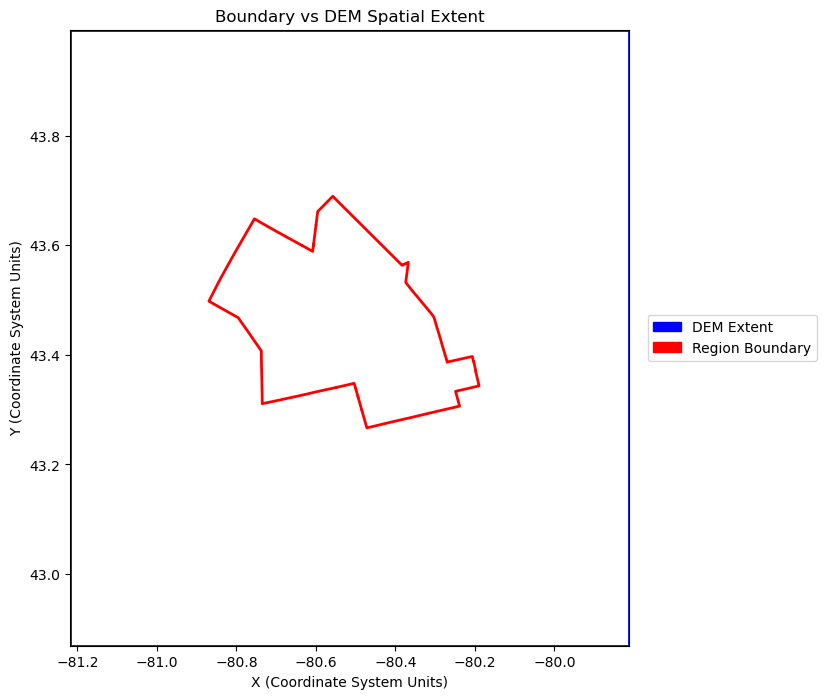

In [55]:
## 9. Visualization of Spatial Overlap

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 8))

# DEM bounding box
dem_rect = box(
    dem.bounds.left,
    dem.bounds.bottom,
    dem.bounds.right,
    dem.bounds.top
)

x_dem, y_dem = dem_rect.exterior.xy
ax.plot(x_dem, y_dem, color="blue", linewidth=2)

# Boundary (actual geometry)
boundary_proj.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

# Axis formatting
ax.set_title("Boundary vs DEM Spatial Extent")
ax.set_xlim(dem.bounds.left, dem.bounds.right)
ax.set_ylim(dem.bounds.bottom, dem.bounds.top)
ax.set_xlabel("X (Coordinate System Units)")
ax.set_ylabel("Y (Coordinate System Units)")

# Manual legend (FIXED)
dem_patch = mpatches.Patch(color="blue", label="DEM Extent")
boundary_patch = mpatches.Patch(color="red", label="Region Boundary")

ax.legend(
    handles=[dem_patch, boundary_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.show()

## 10. Final Compatibility Summary

In [56]:
print("---- COMPATIBILITY REPORT ----")

print("CRS Match:", boundary_proj.crs == dem.crs)
print("Spatial Intersection:", intersects)

if (boundary_proj.crs == dem.crs) and intersects:
    print("STATUS: DATASETS ARE COMPATIBLE FOR CLIPPING")
else:
    print("STATUS: DATASETS REQUIRE FIXES BEFORE ANALYSIS")

---- COMPATIBILITY REPORT ----
CRS Match: True
Spatial Intersection: True
STATUS: DATASETS ARE COMPATIBLE FOR CLIPPING


## 11. Optional: Save Reprojected Boundary

Here we have the option to save the boundary file after converting its coordinate system so we can skip that step next time. If your boundary file was already in the correct coordinate system you wouldn't need to do this. 

In [58]:
boundary_proj.to_file("../../data/boundary_projected.geojson", driver="GeoJSON")

print("Reprojected boundary saved.")

Reprojected boundary saved.
